In [11]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
insurance_data = pd.read_csv('insurance.csv')

In [13]:
insurance_data.sample(10)

,age,sex,bmi,children,smoker,region,charges
286,46,female,48.070,2,no,northeast,9432.92530
340,24,female,27.600,0,no,southwest,18955.22017
1102,29,male,38.940,1,no,southeast,3471.40960
399,18,female,38.170,0,no,southeast,1631.66830
406,33,female,24.310,0,no,southeast,4185.09790
531,62,female,31.730,0,no,northeast,14043.47670
58,53,female,22.880,1,yes,southeast,23244.79020
378,64,female,30.115,3,no,northwest,16455.70785
493,61,male,43.400,0,no,southwest,12574.04900
1213,52,female,33.300,2,no,southwest,10806.83900


In [14]:
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

In [15]:
X["sex"] = X["sex"].map({"male": 1, "female": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})
X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)
X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]
X.sample(10)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
836,36,1,31.500,0,0,0,0,1,0,0.000
1036,22,1,37.070,2,1,0,1,0,22,37.070
827,36,1,28.025,1,1,0,0,0,36,28.025
997,63,0,36.850,0,0,0,1,0,0,0.000
635,64,1,38.190,0,0,0,0,0,0,0.000
281,54,1,40.565,3,1,0,0,0,54,40.565
897,19,1,25.555,1,0,1,0,0,0,0.000
887,36,0,30.020,0,0,1,0,0,0,0.000
1170,18,1,27.360,1,1,0,0,0,18,27.360
229,47,1,25.460,2,0,0,0,0,0,0.000


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Lasso Regression
alpha_values = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 15, 20, 25, 50]
mse_values = []
r2_values = []

for alpha in alpha_values:
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_values.append(mse)
    r2_values.append(r2)

print("Alpha\tMSE\t\tR-squared")
for i in range(len(alpha_values)):
    print(f"{alpha_values[i]}\t{mse_values[i]:.2f}\t{r2_values[i]:.4f}")


Alpha	MSE		R-squared
0.001	20922599.87	0.8652
0.01	20922527.33	0.8652
0.1	20921803.70	0.8652
0.5	20918648.89	0.8653
1	20914832.64	0.8653
5	20890881.00	0.8654
10	20872844.79	0.8656
15	20868495.29	0.8656
20	20877828.53	0.8655
25	20900842.59	0.8654
50	21196929.87	0.8635


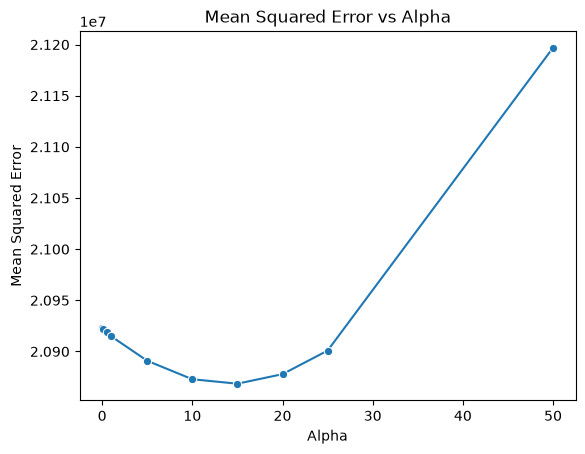

In [18]:
sns.lineplot(x=alpha_values, y=mse_values, marker="o")
plt.title("Mean Squared Error vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Mean Squared Error")
plt.show()

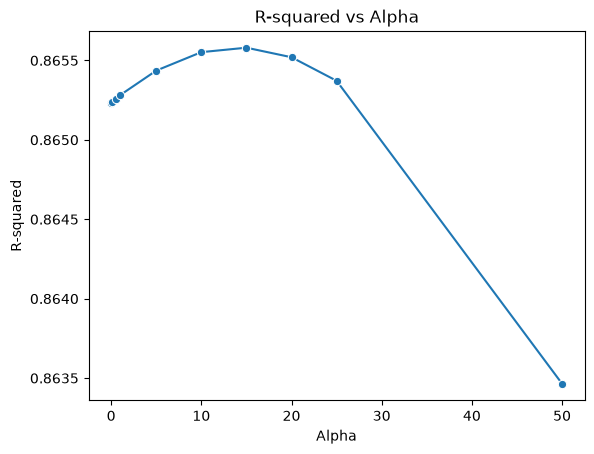

In [19]:
sns.lineplot(x=alpha_values, y=r2_values, marker="o")
plt.title("R-squared vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("R-squared")
plt.show()

In [27]:
from sklearn.linear_model import LassoCV
alpha_values = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 15, 20, 25, 50] 
lasso_cv_model = LassoCV(alphas=alpha_values, cv=5, max_iter=1000,  random_state=42)

lasso_cv_model.fit(X_train, y_train)

print(f"Optimal alpha: {lasso_cv_model.alpha_}")

y_pred_cv = lasso_cv_model.predict(X_test)
mse_cv = mean_squared_error(y_test, y_pred_cv)
r2_cv = r2_score(y_test, y_pred_cv)

print(f"MSE: {mse_cv}, R2: {r2_cv}")

Optimal alpha: 0.001
MSE: 20922599.871035974, R2: 0.8652317499151698
